In [21]:
import uproot
import pandas as pd
import numpy as np
import glob


In [22]:
import matplotlib.pyplot as plt
plt.style.use('default')
plt.style.use('belle2')

import os

In [23]:
import glob

base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/proc13/proc13_etaetapip_loose_v7_250122_temp"
cm_elements = ["etahp_13_had_4S_off_v1", "etahp_13_had_4S_v3", "etahp_23_had_4S_off_v1", "etahp_23_had_4S_v1", "etahp_23_had_5Sscan_10657_v1", "etahp_23_had_5Sscan_10706_v1",\
               "etahp_23_had_5Sscan_10751_v1", "etahp_23_had_5Sscan_10810_v1"]
base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/proc13_all/proc13_all_etapip_loose_v7_250216_CMS_Psum"
cm_elements = ["etahp_13_4S_off_v1", "etahp_13_4S_v2", "etahp_23_4S_off_v1", "etahp_23_4S_v1", "etahp_23_5Sscan_10657_v1", "etahp_23_5Sscan_10706_v1",\
               "etahp_23_5Sscan_10751_v1", "etahp_23_5Sscan_10810_v1"]

cut_expression = "Dp_M>0"
tree_name = "etapip_pipipi_K"

file_list = []
for element in cm_elements:
    # pattern = f"{base_path}/{element}/*.root"
    pattern = f"{base_path}/{element}/{tree_name}/new_FOM/*.BCS.root"

    file_list += glob.glob(pattern)


dataframes = []
# Process each file
for file_name in file_list:
    # Load the ROOT file and tree
    file = uproot.open(file_name)
    tree = file[tree_name]

    # Specify the branches you want to extract
    # branches = ['Pip_pionID','Dp_Psum','Pip_genMotherID','etapip_Eta_genMotherID','Pip_genMotherPDG','etapip_Eta_genMotherPDG','Dp_cosHelicityAngleMomentum','Pip_dr',"Dp_isSignal","Dp_cosAngleBetweenMomentumAndVertexVectorInXYPlane", "Pip_p","Dp_CMS_p","etapip_Eta_p","CFT_prob","Dp_M","num_Dstar_no_nan",]  # Replace with actual branch names

    branches = ['Dp_M','Dp_CMS_cosTheta','Pip_cosTheta','Pip_p','Pip_charge']
    # Convert the selected branches to a Pandas DataFrame
    # df_temp = tree.arrays(branches, library="pd")
    df_temp = tree.arrays(
        branches,
        library="pd",
        entry_start=None,  # Optional: start at a specific entry
        entry_stop=None,   # Optional: stop at a specific entry
        filter_name=branches,  # Load only specified branches
        cut=cut_expression  # Apply the cut
    )
    # df_temp = tree.arrays(library="pd")

    # Append the DataFrame to the list
    dataframes.append(df_temp)

In [24]:
df_proc13 = pd.concat(dataframes, ignore_index=True)


In [25]:
df_proc13.describe()

,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge
count,17089.000000,17089.000000,17089.000000,17089.000000,17089.000000
mean,1.661960,0.144430,0.391635,1.649629,-0.009187
std,0.134108,0.494157,0.477570,0.751581,0.999987
min,1.500001,-0.939600,-0.884499,0.400289,-1.000000
25%,1.572709,-0.301678,0.005709,1.063265,-1.000000
50%,1.630095,0.202265,0.532428,1.549975,-1.000000
75%,1.708331,0.587432,0.822182,2.135158,1.000000
max,2.099920,0.997673,0.975832,4.848993,1.000000


In [26]:
df_proc13 = df_proc13.query('Dp_M> 1.73 & Dp_M<2.1')


In [27]:
df_proc13.describe()

,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge
count,3633.000000,3633.000000,3633.000000,3633.000000,3633.000000
mean,1.868024,0.178598,0.442538,1.719521,-0.011836
std,0.133694,0.509709,0.497884,0.818261,1.000068
min,1.730026,-0.933112,-0.884499,0.400625,-1.000000
25%,1.765521,-0.271528,0.045923,1.092293,-1.000000
50%,1.800309,0.263584,0.639016,1.648838,-1.000000
75%,2.038614,0.627361,0.876807,2.237498,1.000000
max,2.099920,0.997673,0.971887,4.848993,1.000000


In [28]:
nan_columns = df_proc13.isnull().any()
print(nan_columns)

Dp_M               False
Dp_CMS_cosTheta    False
Pip_cosTheta       False
Pip_p              False
Pip_charge         False
dtype: bool


In [29]:
import glob

base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/etapip_eteeta/MC15rd_etaetapip_loose_v7_241213_temp"
base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/etapip_eteeta/MC15rd_etaetapip_loose_v7_250122_skimhad_if_true_Dp_CMS_p"
cm_elements = ["15rd_eta_e7_18_4S_v3", "15rd_eta_e20_b26_v1", "15rd_eta_e20_e26_4S_v2", "15rd_eta_e21_5S_scan_v1", "15rd_eta_mori_off_v1"]
cut_expression = "Dp_M>0"
tree_name = "etapip_pipipi_K"

file_list = []
for element in cm_elements:
    # pattern = f"{base_path}/{element}/*.root"
    # pattern = f"{base_path}/{element}/{tree_name}/*.BCS.root"
    pattern = f"{base_path}/{element}/{tree_name}/train_Dp_dz/skimhad/new_FOM/*.BCS.root"

    file_list += glob.glob(pattern)


dataframes = []
# Process each file
for file_name in file_list:
    # Load the ROOT file and tree
    file = uproot.open(file_name)
    tree = file[tree_name]

    # Specify the branches you want to extract
    # branches = ['Pip_pionID','Dp_Psum','Pip_genMotherID','etapip_Eta_genMotherID','Pip_genMotherPDG','etapip_Eta_genMotherPDG','Dp_cosHelicityAngleMomentum','Pip_dr',"Dp_isSignal","Dp_cosAngleBetweenMomentumAndVertexVectorInXYPlane", "Pip_p","Dp_CMS_p","etapip_Eta_p","CFT_prob","Dp_M","num_Dstar_no_nan",]  # Replace with actual branch names

    branches = ['Dp_M','Dp_CMS_cosTheta','Pip_cosTheta','Pip_p','Pip_charge']
    # Convert the selected branches to a Pandas DataFrame
    # df_temp = tree.arrays(branches, library="pd")
    df_temp = tree.arrays(
        branches,
        library="pd",
        entry_start=None,  # Optional: start at a specific entry
        entry_stop=None,   # Optional: stop at a specific entry
        filter_name=branches,  # Load only specified branches
        cut=cut_expression  # Apply the cut
    )
    # df_temp = tree.arrays(library="pd")

    # Append the DataFrame to the list
    dataframes.append(df_temp)

In [30]:
df_mc15rd = pd.concat(dataframes, ignore_index=True)


In [31]:
df_mc15rd.describe()

,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge
count,68158.000000,68158.000000,68158.000000,68158.000000,68158.000000
mean,1.727599,0.137982,0.393553,1.664039,-0.002289
std,0.165149,0.496050,0.474015,0.761327,1.000005
min,1.500013,-0.970017,-0.898631,0.400018,-1.000000
25%,1.589287,-0.297501,0.006297,1.077045,-1.000000
50%,1.683427,0.194839,0.529920,1.555342,-1.000000
75%,1.866083,0.579360,0.824237,2.146025,1.000000
max,2.099990,0.997599,0.974059,5.246625,1.000000


In [32]:
df_mc15rd = df_mc15rd.query('Dp_M> 1.73 & Dp_M<2.1')


In [33]:
df_mc15rd.describe()

,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge
count,28074.000000,28074.000000,28074.000000,28074.000000,28074.000000
mean,1.900183,0.156333,0.425572,1.692493,-0.002351
std,0.099053,0.495511,0.475763,0.794614,1.000015
min,1.730012,-0.951259,-0.895093,0.400119,-1.000000
25%,1.811342,-0.265494,0.047620,1.086374,-1.000000
50%,1.905427,0.220759,0.580738,1.585377,-1.000000
75%,1.970659,0.589398,0.854805,2.177457,1.000000
max,2.099990,0.997599,0.974059,5.246625,1.000000


In [34]:
nan_columns = df_mc15rd.isnull().any()
print(nan_columns)

Dp_M               False
Dp_CMS_cosTheta    False
Pip_cosTheta       False
Pip_p              False
Pip_charge         False
dtype: bool


In [35]:
from plothist import make_hist, plot_hist
from plothist import plot_two_hist_comparison, add_luminosity


In [36]:
tree_to_compare = tree_name
plt.rcParams['font.family'] = 'DejaVu Sans'


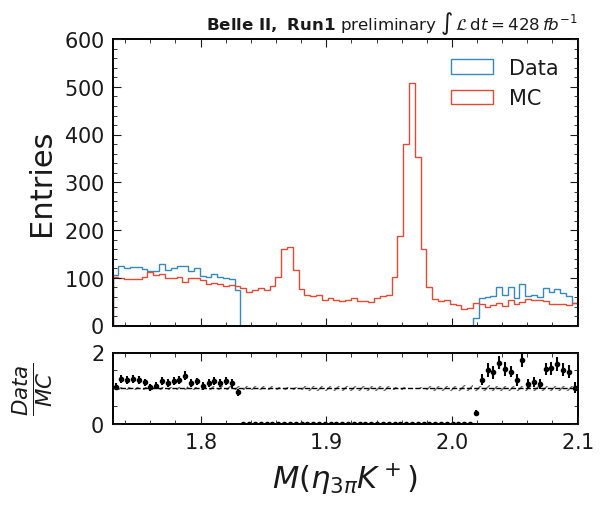

In [37]:
name = "Dp_M"
category = "category"
xlabel = r"$M(\eta_{3\pi} K^+)$"

# x1 = df[name][df[category] == 1]
# x2 = df[name][df[category] == 2]

x1 = df_proc13[name]
x2 = df_mc15rd[name]

# x_range = (min(min(x1), min(x2)), max(max(x1), max(x2)))
# x_range = (min(min(x1), min(x2)),5.1)
x_range = (1.73,2.1)

h1 = make_hist(x1, bins=80, range=x_range, weights=1)
h2 = make_hist(x2, bins=80, range=x_range, weights=1/4)


# Default comparison is ratio
fig, ax_main, ax_comparison = plot_two_hist_comparison(
    h1,
    h2,
    xlabel=xlabel,
    ylabel="Entries",
    h1_label="Data",
    h2_label="MC",
    comparison="split_ratio",
)
add_luminosity(
    collaboration="Belle II, Run1", ax=ax_main, lumi=428, lumi_unit="fb", preliminary=True
)
fig.savefig(f"proc13_MC15rd_{tree_to_compare}_{name}_skimhad_new_FOM.png", bbox_inches="tight")